# Analysis of SW XQNN No-Gradient Results
Compatible with Qiskit 1.2.4+

### Author
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation. In association with IEEE Conference Trends in Quantum Computing and Emerging Business Technologies - TQCEBT 2022
- May 2024: Compatibility upgrade to Qiskit 1.2.4+
- Feb 2025: Addition of model instances and split between data analysis and charting

### Aims
> *This script aims to analyse history of training quantum neural network with sliding-windows of time-series data.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

In [1]:
import sys
sys.path.append('.')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.']

In [2]:
import os
import numpy as np
import pylab
import math
import json
import time
import copy
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Target import *
from utils.Window import *
from utils.TS import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Libraries used in QTSA development

from IPython.display import clear_output
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit
from qiskit_algorithms.optimizers import L_BFGS_B, P_BFGS, COBYLA, NELDER_MEAD, QNSPSA, ADAM, UMDA
from qiskit_algorithms.optimizers import SPSA
from qiskit.circuit.library import RealAmplitudes, TwoLocal, ZFeatureMap, ZZFeatureMap,EfficientSU2, PauliFeatureMap
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_algorithms.utils import algorithm_globals
from qiskit.visualization import plot_histogram, plot_state_city, plot_state_paulivec
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.utils.loss_functions import L1Loss, L2Loss
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit_machine_learning.gradients import LinCombEstimatorGradient, DerivativeType
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
### Listing control
debug = True
seed = 2022

### Software version
MAJOR = 9
MINOR = 12

### Constants
LOG_NAME = 'log_4_iter'
CASE_NAME = 'xqnn_ng'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('log_4_iter',
 'xqnn_ng',
 '2_sins_sw',
 'log_4_iter/data',
 'log_4_iter/training',
 'log_4_iter/analysis',
 'log_4_iter/figures')

## Fetch all source data
**<font color="red">Enter the name of the DATA_ID</font>**<br/>
*Note that this is windowed data (as indicated by "sw" in the data ID)*

In [5]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [6]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [7]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



## Fetch all training meta-data
**<font color="red">Enter the name of the TRAIN_ID</font>**

In [8]:
### Training parameters

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   l: number of layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs
TRAIN_ID = '2_sins_sw_xqnn_ng_n70_z0_q5_in5_fm1_anz5_L_BFGS_B_ep60'
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/info.json'
train_info_fpath

'log_4_iter/training/2_sins_sw_xqnn_ng_n70_z0_q5_in5_fm1_anz5_L_BFGS_B_ep60/info.json'

In [9]:
## Fetch all training parameters
### Reading the info file
train_info = read_json_file(train_info_fpath)

print(f'\nLoaded time series from a file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
print()

### Get info details
CASE_NAME = train_info['case_name']
DATA_NAME = train_info['data_name']
MAJOR = train_info['major_version'] 
MINOR = train_info['minor_version']
samples = train_info['data_sample']
train_pc = train_info['data_split']
noise = train_info['data_noise']

qubits = train_info['ansatz_qubits']
inputs = train_info['ansatz_inputs']
fm_layers = train_info['ansatz_fm_layers']
anz_layers = train_info['ansatz_anz_layers']
ent = train_info['ansatz_ent']

log_interv = train_info['log_interv']
opt_name = train_info['opt_name']
epochs = train_info['epochs']
shots = train_info['shots']
seed = train_info['seed']
inst_no = train_info['inst_no']
inst_seeds = train_info['inst_seeds']
inst_no = train_info['inst_no']
inst_seeds = train_info['inst_seeds']


Loaded time series from a file "log_4_iter/training/2_sins_sw_xqnn_ng_n70_z0_q5_in5_fm1_anz5_L_BFGS_B_ep60/info.json":

	info[case_name] = xqnn_ng
	info[major_version] = 9
	info[minor_version] = 12
	info[data_name] = 2_sins_sw
	info[data_sample] = 70
	info[data_split] = 0.7142857142857143
	info[data_noise] = 0
	info[ansatz_qubits] = 5
	info[ansatz_inputs] = 5
	info[ansatz_fm_layers] = 1
	info[ansatz_anz_layers] = 5
	info[ansatz_ent] = circular
	info[log_interv] = 1
	info[opt_name] = L_BFGS_B
	info[epochs] = 60
	info[shots] = 10000
	info[seed] = 2022
	info[inst_no] = 10
	info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Plot data

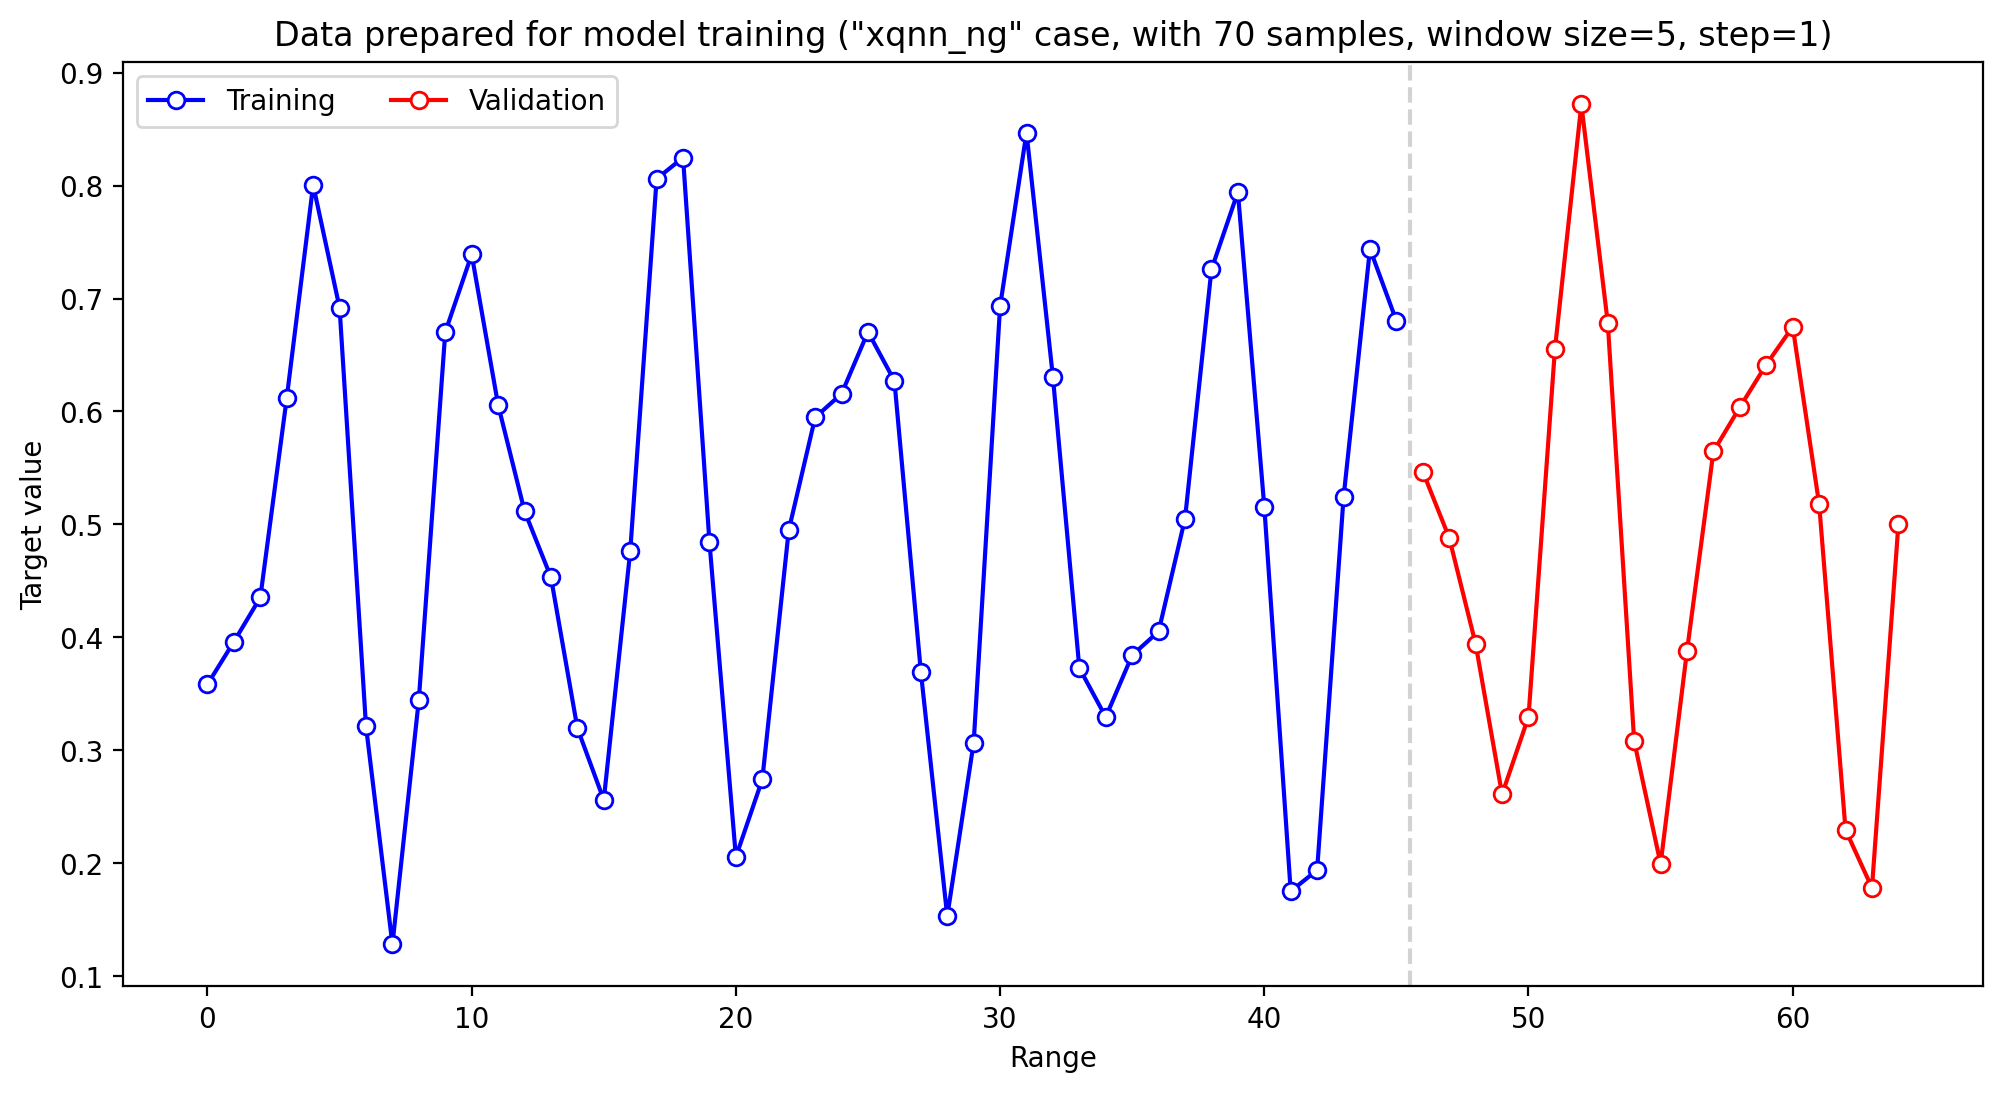

In [10]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['blue', 'red'], marker_colors=['white', 'white', 'lightblue', 'mistyrose'],
    labels = ['Training', 'Validation'], #ylim=(0.1, 1),
    lines = ['solid', 'solid'], markers = ['o', 'o'], legend_cols=2,
    rcParams=(12, 6), dpi=200, 
    title=f'Data prepared for model training ("{CASE_NAME}" case, '+
          f'with {samples} samples, window size={wind_size}, step={wind_step})')
print()

## Fetch all training parameters and cost history

In [11]:
### Reconstruct training prefix
ANALYSIS_PREF = TRAIN_ID

In [12]:
### Collect all instance numbers
inst_list = []
for sel_inst in range(inst_no):
    
    ### Training info files 
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.arr'
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.arr'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.arr'

    ### Check if any of the files are missing
    if  not if_path_exists(init_fpath) or \
        not if_path_exists(history_fpath) or \
        not if_path_exists(params_fpath):
        print(f'*** ERROR: Incomplete instance: {os.path.basename(os.path.dirname(init_fpath))}')
    else:
        inst_list.append(sel_inst)

print(f'\nFound instances: {inst_list}\n')


Found instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [13]:
### Initialise all instance lists
insts_init_weights = []
insts_objfun_vals = []
insts_params_vect = []

### Collect all valid instance data
for sel_inst in inst_list:
    ### Training info files 
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.arr'
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.arr'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.arr'

    ### Read training data
    init_weights = read_ts_file(init_fpath)
    objfun_vals = read_ts_file(history_fpath)
    params_vals = read_ts_file(params_fpath)
    insts_init_weights.append(init_weights)
    insts_objfun_vals.append(objfun_vals)
    insts_params_vect.append(params_vals)

print(f'\nCollected instances: {inst_list}\n')


Collected instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



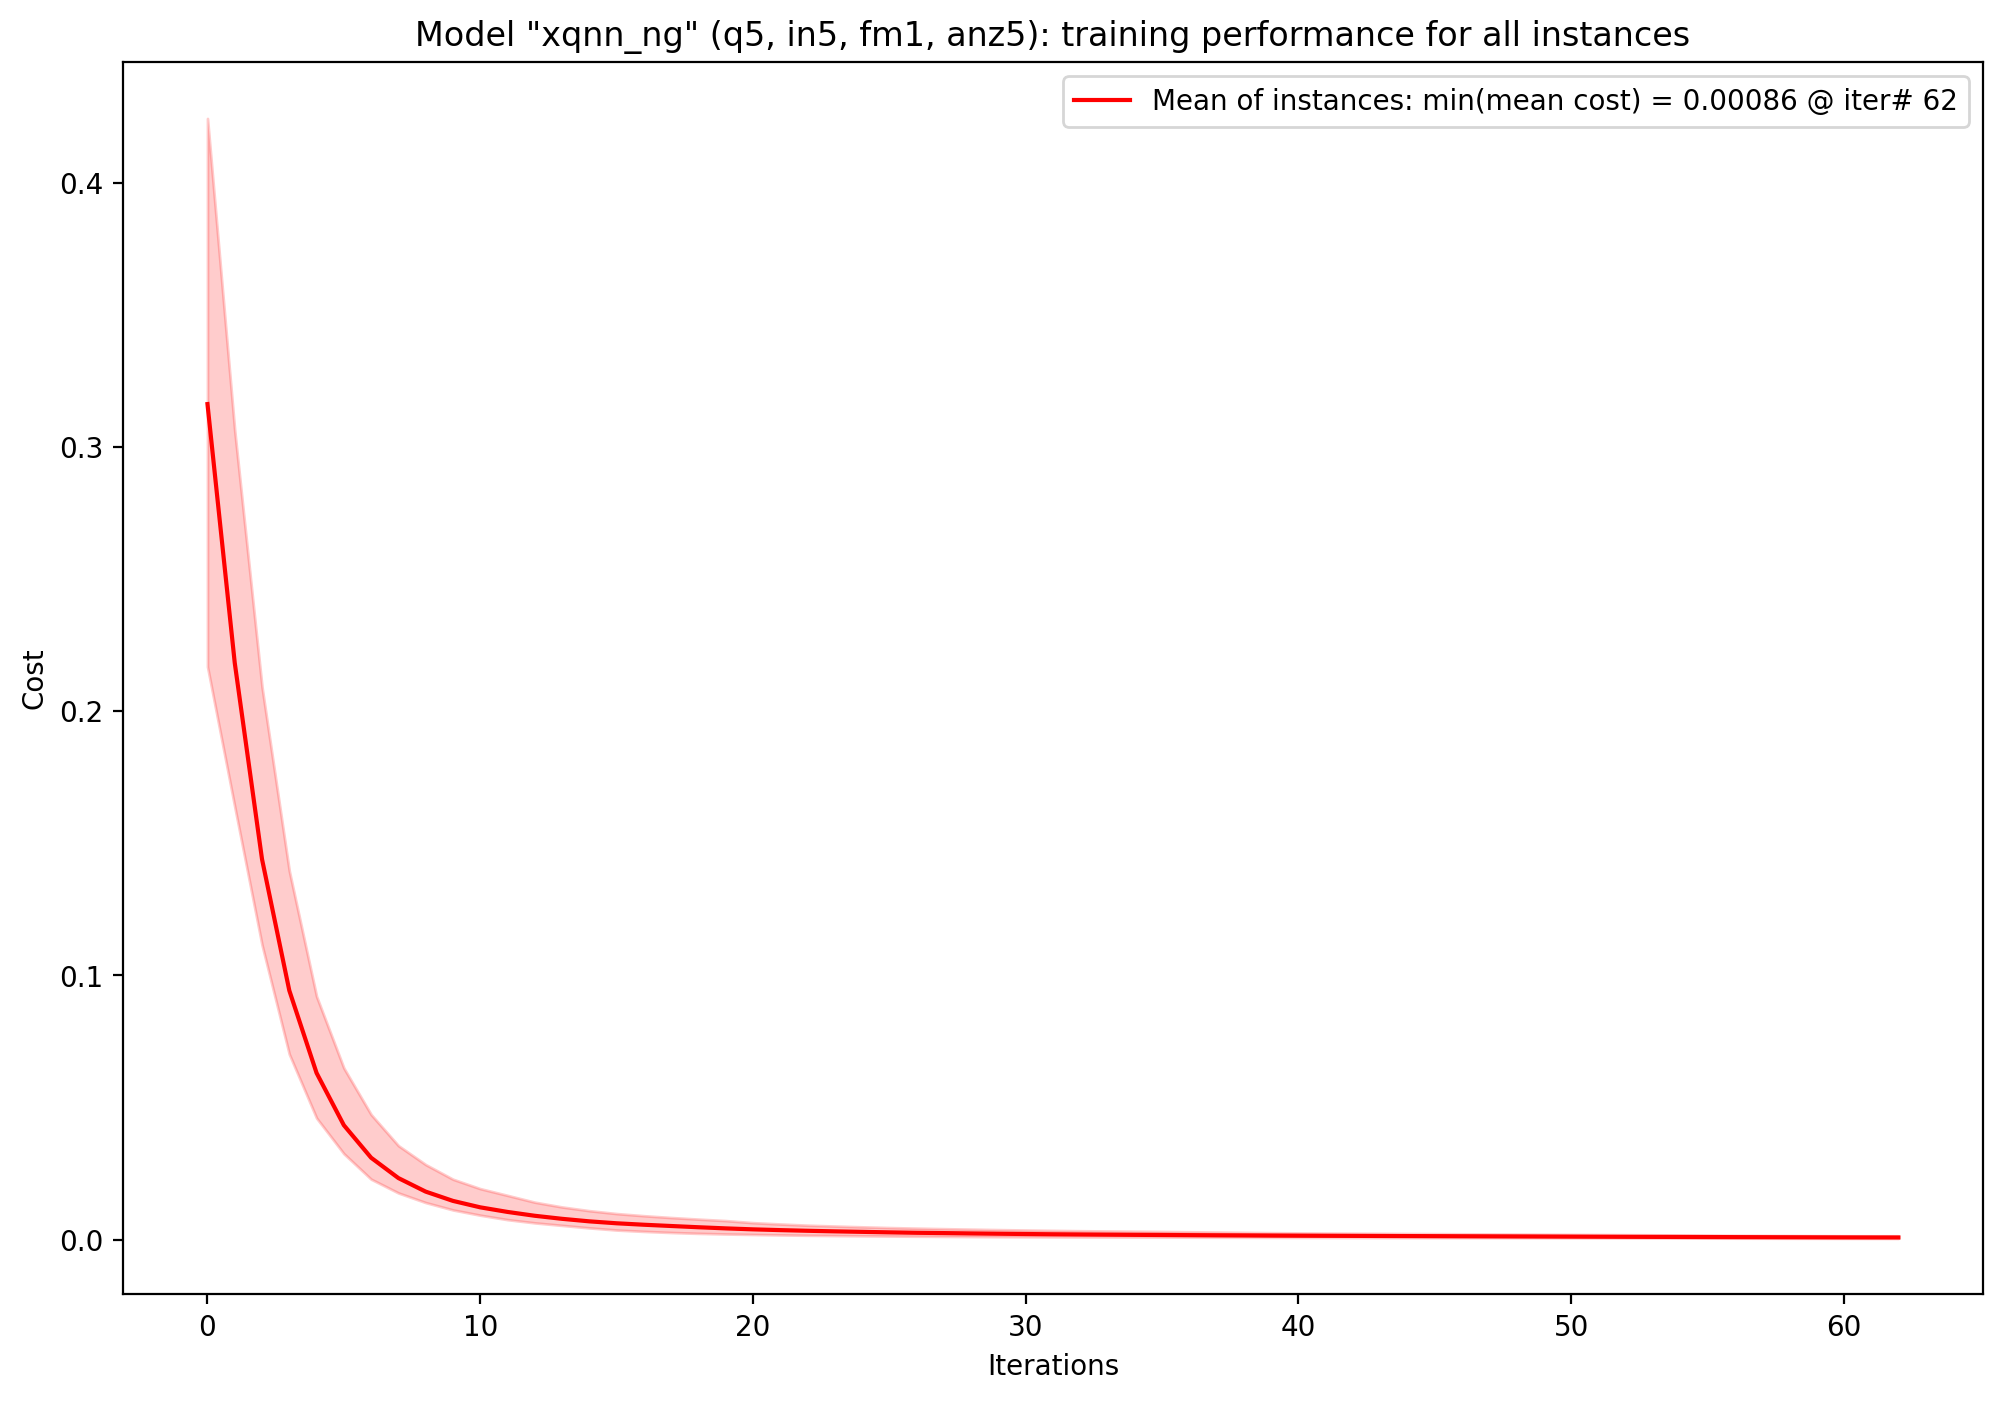

In [14]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'q{qubits}_in{inputs}_fm{fm_layers}_anz{anz_layers}_loaded_cost_range.png'
plot_objfn_range([insts_objfun_vals], smooth_weight=0.4, log_interv=log_interv, ylabel=f'Cost', 
    title=f'Model "{CASE_NAME}" (q{qubits}, in{inputs}, fm{fm_layers}, anz{anz_layers}): training performance for all instances', 
    rcParams=(12, 8), dpi=200, objfn_list=['Mean of instances'], # xlim=(-1, 30),
    save_plot=range_plot_path
    )

## Quantum Neural Network Qiskit Solution

### Identify device

In [15]:
##### Find what devices are available
from qiskit_aer import Aer
from qiskit_aer.backends import AerSimulator
devices = AerSimulator().available_devices()
print(f'Available devices:\t{devices}')

### Priority GPU
device = 'GPU' if ('GPU' in devices) else 'CPU'

### Force CPU for this run
device = 'CPU'
print(f'Selected device:\t{device}')

Available devices:	('CPU', 'GPU')
Selected device:	CPU


In [16]:
from qiskit.primitives import Sampler, Estimator # For "CPU", ignores device="GPU" option
from qiskit_aer.primitives import Sampler as AerSampler, Estimator as AerEstimator # For device="GPU" option

if device == 'GPU':
    sampler = AerSampler(
        backend_options={'seed_simulator': seed, 'method': 'statevector', 
                         'device' : device, 'cuStateVec_enable' : True},
        run_options={'seed': seed, 'shots': shots},
        transpile_options={'seed_transpiler': seed},
    )
    
    estimator = AerEstimator(
        backend_options={'seed_simulator': seed, 'method': 'statevector', 
                         'device' : device, 'cuStateVec_enable' : True},
        run_options={'seed': seed, 'shots': shots},
        transpile_options={'seed_transpiler': seed},
    )
else:
    sampler = Sampler()
    estimator = Estimator()

## Create an XQNN model and test it


Example: Inputs#=5, Qubits#=5, Weight params#=90, FM Layer#=1, ANZ Layer#=5




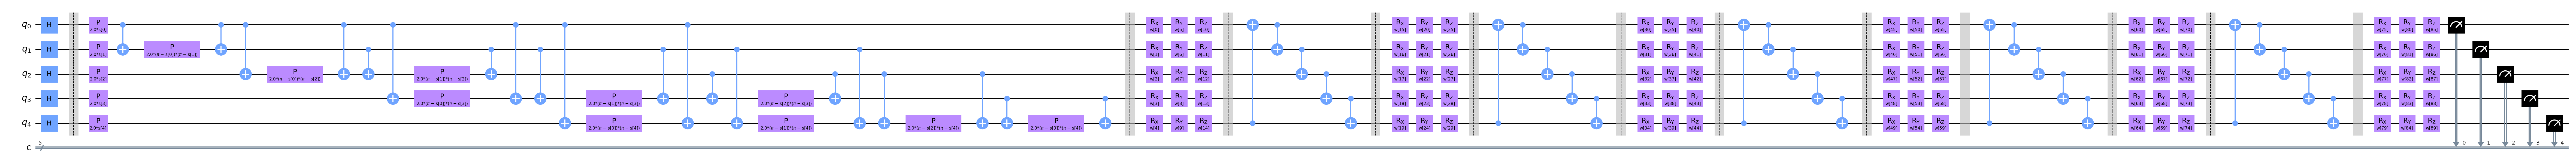

In [17]:
# Test a sample QNN model
test_qubits = qubits; test_inputs= inputs; test_fm_layers = fm_layers;
test_anz_layers = anz_layers; test_ent = ent
test_m, test_input_params, test_weight_params = \
    swindow_qnn_model(test_qubits, test_inputs, test_fm_layers, test_anz_layers, ent=test_ent, add_meas=True)

# print(f'QNN Params: {m.parameters}\n')
# print(f'Input params:\n{input_params}')
# print(f'\nWeight params:\n{weight_params}')
print(f'\nExample: Inputs#={len(test_input_params)}, Qubits#={test_qubits}, Weight params#={len(test_weight_params)}, FM Layer#={test_fm_layers}, ANZ Layer#={test_anz_layers}')

print()
test_m.draw(output='mpl', style='clifford', fold=False, scale=0.7)
print()

## Analysis and reporting

### Score the model using Qiskit V1 primitives

In [18]:
### Utility

# Define output interpretations (sampler)
output_shape = 2
parity = lambda x: "{:b}".format(x).count("1") % 2
first_only = lambda x: x % 2
identity_interpret = lambda x: x

# Define observables (estimator)
op = SparsePauliOp.from_list([("Z" * qubits, 1)]) 
op1 = SparsePauliOp.from_list([("I" * qubits, 0.5), ("Z" * qubits, 0.5)])
op2 = SparsePauliOp.from_list([("I" * qubits, 0.5), ("Z" * qubits, -0.5)])

In [19]:
##### Calculate the score

### Init predictions for all instances
insts_train_preds = []
insts_test_preds = []

### Init scores
insts_train_mae_scores = []
insts_train_mse_scores = []
insts_train_r2_scores = []
insts_test_mae_scores = []
insts_test_mse_scores = []
insts_test_r2_scores = []

# Init MSE tracking
min_test_mse = 100000
min_test_mse_idx = 0

### Collect all instance data
start = time.time()
for inst_idx in tqdm(range(len(inst_list)), desc=f"Instances progress: "):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Start a random process
    algorithm_globals.random_seed = inst_seeds[sel_inst]
    np.random.seed(inst_seeds[sel_inst])

    ### Init predictions
    train_preds = []
    test_preds = []

    ### Init scores
    train_mae_scores = []
    train_mse_scores = []
    train_r2_scores = []
    test_mae_scores = []
    test_mse_scores = []
    test_r2_scores = []
    
    ### Fetch the instance parameters
    params_vals = insts_params_vect[inst_idx]

    ### Score calculation and collection
    for param_no in tqdm(range(params_vals.shape[0]), leave=False,
                         desc=f'Instance {sel_inst:03d} progress: '):
        
        # Define model, its parameters and their values
        model, input_params, weight_params = swindow_qnn_model(qubits, inputs, fm_layers, anz_layers, ent=ent)
        sel_weights = params_vals[param_no]
        
        # Prepare data and gradients
        # pm = generate_preset_pass_manager(backend=sim, optimization_level=1)
        # pm_model = pm.run(model)
        
        # gradient = LinCombEstimatorGradient(estimator)
        # gradient = ParamShiftEstimatorGradient(estimator)
        # gradient = SPSAEstimatorGradient(estimator)
    
        estim_qnn = EstimatorQNN(
            # circuit=pm_model,
            circuit=model,
            input_params=model.parameters[:inputs],
            weight_params=model.parameters[inputs:],
            observables=op, # [op1, op2],
            estimator=estimator,
            # gradient=gradient,
        )
    
        # Calculate results
        yp_train_true = y_train_ts
        yp_valid_true = y_valid_ts
        yp_train_hat = estim_qnn.forward(X_train_ts, sel_weights)
        yp_valid_hat = estim_qnn.forward(X_valid_ts, sel_weights)
    
        # Score results
        train_mae = mean_absolute_error(yp_train_true, yp_train_hat)
        train_mse = mean_squared_error(yp_train_true, yp_train_hat)
        train_r2 = r2_score(yp_train_true, yp_train_hat)
        test_mae = mean_absolute_error(yp_valid_true, yp_valid_hat)
        test_mse = mean_squared_error(yp_valid_true, yp_valid_hat)
        test_r2 = r2_score(yp_valid_true, yp_valid_hat)
    
        # Check if this instance has the best test MSE
        this_min_test_mse = np.min(test_mse)
        if this_min_test_mse < min_test_mse:
            min_test_mse = this_min_test_mse
            min_test_mse_idx = inst_idx
    
        # Add predictions to their lists
        train_preds.append(yp_train_hat.flatten())
        test_preds.append(yp_valid_hat.flatten())

        # Add scores to their lists
        train_mae_scores.append(train_mae)
        train_mse_scores.append(train_mse)
        train_r2_scores.append(train_r2)
        test_mae_scores.append(test_mae)
        test_mse_scores.append(test_mse)
        test_r2_scores.append(test_r2)

    insts_train_preds.append(train_preds)
    insts_test_preds.append(test_preds)
    insts_train_mae_scores.append(train_mae_scores)
    insts_train_mse_scores.append(train_mse_scores)
    insts_train_r2_scores.append(train_r2_scores)
    insts_test_mae_scores.append(test_mae_scores)
    insts_test_mse_scores.append(test_mse_scores)
    insts_test_r2_scores.append(test_r2_scores)

elapsed = time.time() - start

Instances progress:   0%|          | 0/10 [00:00<?, ?it/s]

Instance 000 progress:   0%|          | 0/63 [00:00<?, ?it/s]

Instance 001 progress:   0%|          | 0/63 [00:00<?, ?it/s]

Instance 002 progress:   0%|          | 0/63 [00:00<?, ?it/s]

Instance 003 progress:   0%|          | 0/62 [00:00<?, ?it/s]

...

Instance 005 progress:   0%|          | 0/61 [00:00<?, ?it/s]

Instance 006 progress:   0%|          | 0/63 [00:00<?, ?it/s]

Instance 007 progress:   0%|          | 0/61 [00:00<?, ?it/s]

Instance 008 progress:   0%|          | 0/62 [00:00<?, ?it/s]

Instance 009 progress:   0%|          | 0/62 [00:00<?, ?it/s]

In [20]:
print(f'\nMinimum test MSE: {np.round(min_test_mse, 5)}, '+
      f'found in instance[#{min_test_mse_idx}] = {inst_list[min_test_mse_idx]} / '+
      f'time: {np.round(elapsed, 4)} secs\n')


Minimum test MSE: 0.01019, found in instance[#7] = 7 / time: 135.058 secs



## Save analysis data

In [21]:
print(f'\nSaved model scores for instances: ', end='')
for inst_idx in range(len(inst_list)):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Training info files 
    train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.arr'
    train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.arr'
    train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.arr'
    train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.arr'

    test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.arr'
    test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.arr'
    test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.arr'
    test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.arr'
    train_mae_scores_fpath

    ### Save the scores
    write_ts_file(train_preds_fpath, insts_train_preds[inst_idx])
    write_ts_file(train_mae_scores_fpath, insts_train_mae_scores[inst_idx])
    write_ts_file(train_mse_scores_fpath, insts_train_mse_scores[inst_idx])
    write_ts_file(train_r2_scores_fpath, insts_train_r2_scores[inst_idx])

    write_ts_file(test_preds_fpath, insts_test_preds[inst_idx])
    write_ts_file(test_mae_scores_fpath, insts_test_mae_scores[inst_idx])
    write_ts_file(test_mse_scores_fpath, insts_test_mse_scores[inst_idx])
    write_ts_file(test_r2_scores_fpath, insts_test_r2_scores[inst_idx])

    print(f'{sel_inst} ', end='')

print()


Saved model scores for instances: 0 1 2 3 4 5 6 7 8 9 


## System

In [22]:
import os
import sys
print(f"\nOperating environment:\n")
os.system('lsb_release -d -s')
os.system('python --version')
print(f'Conda {os.path.basename(sys.prefix)}\n')


Operating environment:

Ubuntu 22.04.5 LTS
Python 3.11.11
Conda qiskit-gpu



In [23]:
print(f"\nSignificant Python packages:\n")
os.system('pip list | grep -e qiskit');


Significant Python packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
